In [ ]:
import numpy as np
def analyze(filepath, cut = 10000):
    with open(filepath, 'r') as f:
        content = f.read()

    search_depth = []
    steps = []
    prediction_correctness = []
    visited_positions = []
    visited_criricals = []
    game_info = []

    for s in content.split('@'):
        # print(s)
        # print('------------------')
        # s = s.split('\n')
        if len(s) == 0:
            continue
        step = s.split('\n')[0].split('step')[1]
        step = int(step)
        if step >= cut:
            break
        move = None
        rate = None
        depth = None
        vis = None
        vis_critical = None
        for line in s.split('\n'):
            if "optimal move:" in line:
                move = line.replace("optimal move:", "")
                continue
            if "success rate" in line:
                if 'nan' in line:
                    continue;
                rate = eval(line.replace('success rate: ', ''))
                continue
            if 'depth' in line:
                depth = eval(line.replace('depth:', ''))
            if 'visited positions:' in line:
                vis = eval(line.replace('visited positions:', ''))
            if 'visited criticals:' in line:
                vis_critical = eval(line.replace('visited criticals:', ''))
        if move is None:
            continue

        # print('move:', move)
        # print('rate:', rate)
        # print('depth:', depth)

        round_info = {
            'depth' : depth,
            'prediction rate': rate,
            'move': move,
            'visited': vis,
            'criticals': vis_critical
        }
        if vis is None:
            # print(round_info)
            # print(s)
            break

        steps.append(step)
        search_depth.append(depth)
        prediction_correctness.append(rate)
        game_info.append(round_info)
        visited_positions.append(vis - vis_critical)
        visited_criricals.append(vis_critical)

    search_depth = np.array(search_depth)
    prediction_correctness = np.array(prediction_correctness)
    visited_positions = np.array(visited_positions)
    visited_criricals = np.array(visited_criricals)

    return steps, {
        'depth': search_depth.copy(),
        'prediction' : prediction_correctness.copy(),
        'visited_normal': visited_positions.copy(),
        'criticals': visited_criricals.copy()
    }

In [ ]:
import os
import matplotlib.pyplot as plt

record_path = '/mnt/20F408ADF408876E/TCG/TCG_final/wakasagihime/record'
plt.figure(figsize=(12, 8))

max_step = 80

depth = np.zeros(max_step)
N = np.zeros(max_step)
prediction = np.zeros(max_step)
visited = np.zeros(max_step)
criticals = np.zeros(max_step)

# N = 0

for f in os.listdir(record_path):
    filepath = os.path.join(record_path, f)
    if not '.txt' in filepath:
        continue
    info = analyze(filepath, max_step)

    steps = info[0]
    info = info[1]
    visited_positions = info['visited_normal']
    visited_criricals = info['criticals']
    prediction_correctness = info['prediction']
    search_depth = info['depth']

    depth[steps] += search_depth
    prediction[steps] += prediction_correctness
    visited[steps] += visited_positions
    criticals[steps] += visited_criricals
    N[steps] += 1

steps = range(max_step)

visited /= N
criticals /= N
prediction /= N
depth /= N

plt.subplot(2,2,1)
plt.plot(steps, visited, label = 'visitd')
plt.plot(steps, criticals, label = 'critical')
plt.plot(steps, visited+criticals , label = 'total')
plt.legend()
plt.title('visited normal/critical nodes')

plt.subplot(2,2,2)
plt.plot(steps, prediction)
plt.title('move-ordering corectness')
plt.legend()

plt.subplot(2,2,3)
plt.plot(steps, depth)
plt.ylim(0, 10)
plt.title('search depth')

plt.show()


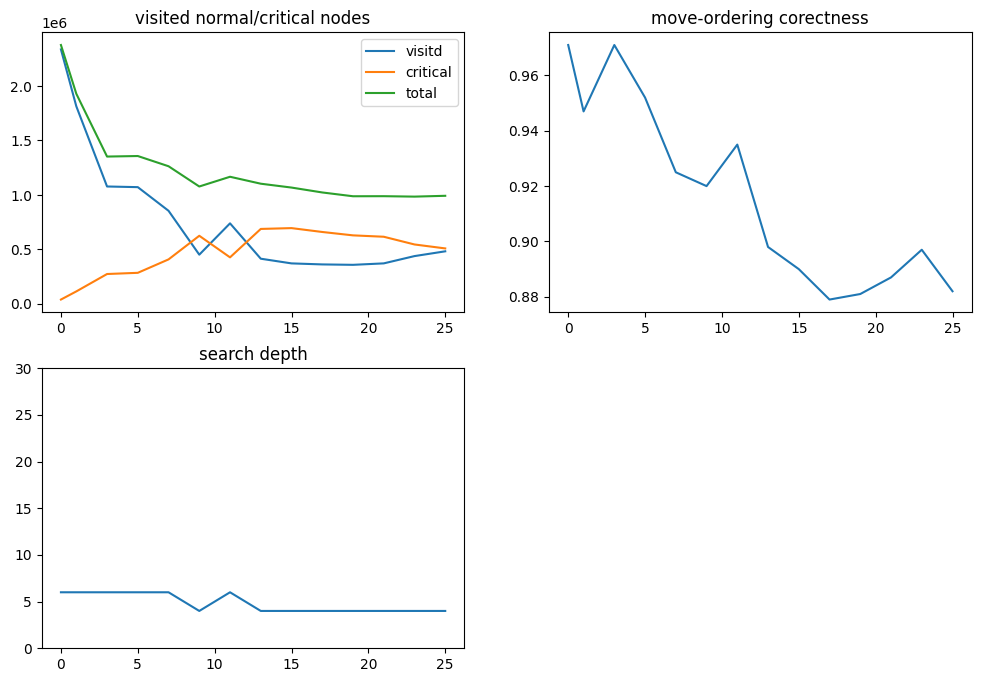

In [9]:
import matplotlib.pyplot as plt
file_path = input()
steps, analyzation = analyze(file_path)

visited_positions = analyzation['visited_normal']
visited_criricals = analyzation['criticals']

prediction_correctness = analyzation['prediction']
search_depth = analyzation['depth']

plt.figure(figsize=(12, 8))
plt.subplot(2,2,1)

plt.plot(steps, visited_positions, label = 'visitd')
plt.plot(steps, visited_criricals, label = 'critical')
plt.plot(steps, [x+y for(x,y) in zip(visited_positions, visited_criricals)], label = 'total')
plt.legend()
plt.title('visited normal/critical nodes')

plt.subplot(2,2,2)
plt.plot(steps, prediction_correctness)
plt.title('move-ordering corectness')
# plt.legend()

plt.subplot(2,2,3)
plt.plot(steps, search_depth)
plt.ylim(0, 30)
plt.title('search depth')

plt.show()

In [ ]:
import matplotlib.pyplot as plt
plt.plot(steps, search_depth)
plt.ylim(0, 30)

In [ ]:
plt.plot(steps, prediction_correctness)
plt.show()